In [41]:
import glob
import re
import numpy as np
import xarray as xr
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.dates as mdates
# geopandas extends pandas to handle geospatial data and perform operations on geographic shapes.
import geopandas as gpd
# matplotlib.colors provides tools to define and manipulate colormaps for visualizations.
import matplotlib.colors as mcolors
# ListedColormap allows the creation of custom colormaps for visualizations.
from matplotlib.colors import ListedColormap
from pathlib import Path
from typing import List
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm
import scipy.stats as stats

In [42]:


def collect_files(base_dir: str, dirs: List[str], subpath: str, pattern: str, exclude: str = None) -> List[str]:
    """
    Collects files matching a pattern from specified subdirectories.

    Parameters:
        base_dir (str): Base directory containing all subdirectories.
        dirs (List[str]): List of subdirectory names.
        subpath (str): Relative path inside each subdirectory where files are located.
        pattern (str): Glob pattern to match files.
        exclude (str, optional): String pattern to exclude from results.

    Returns:
        List[str]: Sorted list of matching file paths as strings.
    """
    all_files = []
    for d in dirs:
        search_path = Path(base_dir) / d / subpath / pattern
        files = sorted(search_path.parent.glob(search_path.name))
        if exclude:
            files = [f for f in files if exclude not in f.name]
        all_files.extend([str(f) for f in files])
    return all_files

# Base directory and subdirectories
base_dir = "/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012"
dirs = [
    "b732-sep-15", "b733-sep-16", 
    "b734-sep-18", "b735-sep-19", "b736-sep-19", "b737-sep-20", "b738-sep-22", 
    "b739-sep-23", "b740-sep-25", "b741-sep-26", "b742-sep-27", "b743-sep-27", 
    "b744-sep-28", "b745-sep-28", "b746-sep-29", "b747-oct-01", "b748-oct-02", 
    "b749-oct-03", "b750-oct-03"
]

# Collect files
core_processed_files = collect_files(base_dir, dirs, "core_processed", "core_faam*r1*.nc", exclude="_1hz")
dry_neph_files = collect_files(base_dir, dirs, "mo-non-core", "metoffice*neph1*.nc")
flight_sum_files = collect_files(base_dir, dirs, ".", "flight-sum*.txt")
sp2_files = collect_files(base_dir, dirs, "non-core", "man-sp2*.na")
ams_files = collect_files(base_dir, dirs, "non-core", "man-ams*.na")

# Example: print or pass them into other analysis
# print(core_processed_files)


In [43]:
# Function to extract flight number (e.g., "b734") from a file path
def extract_flight_number(file_path):
    match = re.search(r'b\d{3}', file_path)
    return match.group(0) if match else None  # Returns None if no match

# Get flight numbers for each dataset
flights_nc = {extract_flight_number(f) for f in core_processed_files}
flights_ams = {extract_flight_number(f) for f in dry_neph_files}
flights_sp2 = {extract_flight_number(f) for f in sp2_files}
flights_neph = {extract_flight_number(f) for f in ams_files}
flights_sum = {extract_flight_number(f) for f in flight_sum_files}

# Find flights that are in all three datasets
common_flights = flights_nc & flights_ams & flights_sp2 & flights_neph & flights_sum # Set intersection

# Filter the file lists to include only matching flights
filtered_nc = [f for f in core_processed_files if extract_flight_number(f) in common_flights]
filtered_ams = [f for f in ams_files if extract_flight_number(f) in common_flights]
filtered_sp2 = [f for f in sp2_files if extract_flight_number(f) in common_flights]
filtered_neph = [f for f in dry_neph_files if extract_flight_number(f) in common_flights]
filtered_sum = [f for f in flight_sum_files if extract_flight_number(f) in common_flights]

# Print the results
print(f"Common flights: {sorted(common_flights)}")
print(f"Filtered NC files: {len(filtered_nc)}")
print(f"Filtered AMS files: {len(filtered_ams)}")
print(f"Filtered SP2 files: {len(filtered_sp2)}")
print(f"Filtered Neph files: {len(filtered_sp2)}")
print(f"Filtered Flight sum files: {len(filtered_sum)}")

Common flights: ['b734', 'b737', 'b739', 'b740', 'b741', 'b742', 'b743', 'b744', 'b745', 'b746', 'b747', 'b748', 'b749', 'b750']
Filtered NC files: 14
Filtered AMS files: 14
Filtered SP2 files: 14
Filtered Neph files: 14
Filtered Flight sum files: 14


In [44]:
def convert_time_to_datetime_sp2(dsf, start_date_str):
    """
    Convert the 'Time_start_UTC' variable (seconds from 00:00 UTC) into datetime format.
    
    Parameters:
    - ds (xarray.Dataset): The dataset containing 'Time_start_UTC'
    - start_date_str (str): Start date in "YYYY MM DD" format
    
    Returns:
    - xarray.Dataset: Dataset with a new 'datetime' coordinate
    """
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y%m%d")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    time_seconds = dsf["Time_UTC"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds])

    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("time", datetime_values))

    return dsf
    
def convert_time_to_datetime_ams(dsf, start_date_str):
    """
    Convert the 'Time_start_UTC' variable (seconds from 00:00 UTC) into datetime format.
    
    Parameters:
    - ds (xarray.Dataset): The dataset containing 'Time_start_UTC'
    - start_date_str (str): Start date in "YYYY MM DD" format
    
    Returns:
    - xarray.Dataset: Dataset with a new 'datetime' coordinate
    """
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y%m%d")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    time_seconds = dsf["Time_start_UTC"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds])

    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("time", datetime_values))

    return dsf
    
def convert_time_to_datetime_neph(dsf, start_date_str):
    
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y%m%d")

    key_options = ["neph_spm", "NEPH_SPM"]  # Possible variations of the key
    matching_key = next((key for key in key_options if key in dsf), None)
    
    if matching_key:
        time_seconds_t = dsf[matching_key].values
    else:
        raise KeyError("Variable 'neph_spm' not found in dataset.")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    #time_seconds = dsf["neph_spm"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds_t])

    dsf = dsf.assign_coords(time=dsf['neph_spm'])
    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("time", datetime_values))
    #dsf["Times"] = (("time",), datetime_values)
    #dsf["datetime"] = (("time",), datetime_values)
    #dsf = dsf.set_coords('neph_spm')

    return dsf

In [45]:
def dataset_sp2_ams_neph(file_path_sp2,file_path_ams,file_path_neph):

    with open(file_path_sp2, "rb") as f:
        lines_sp2 = f.readlines()  # Read the first 100 bytes
    with open(file_path_ams, "rb") as f:
        lines_ams = f.readlines()  # Read the first 100 bytes
        
    metadata_lines_sp2 = lines_sp2[:39]  # 39 lines are metadata
    header_line_sp2 = metadata_lines_sp2[38].strip().split()  # Extract header names
    # Decode if header contains byte strings
    header_line_sp2 = [h.decode("utf-8") if isinstance(h, bytes) else h for h in header_line_sp2]
    # Decode if metadata contains byte strings
    metadata_lines_sp2 = [line.decode("utf-8").strip() if isinstance(line, bytes) else line.strip() for line in metadata_lines_sp2]
    #print(header_line_sp2)

    metadata_lines_ams = lines_ams[:46]   # 46 lines are metadata
    header_line_ams = metadata_lines_ams[45].strip().split()  # Extract header names
    # Decode if header contains byte strings
    header_line_ams = [h.decode("utf-8") if isinstance(h, bytes) else h for h in header_line_ams]
    # Decode if metadata contains byte strings
    metadata_lines_ams = [line.decode("utf-8").strip() if isinstance(line, bytes) else line.strip() for line in metadata_lines_ams]
    #print(header_line_ams)

    data_lines_sp2 = lines_sp2[39:]  # Actual data starts after metadata
    data_lines_ams = lines_ams[46:]
    
    # Parse data into a NumPy array
    data_array = np.array([line.strip().split() for line in data_lines_sp2], dtype=float)
    
    # Define dimensions (assuming first column is time and others are variables)
    dims = ("time", "variable")  # Modify as needed
    time_coords = np.arange(data_array.shape[0])  # Placeholder for time index
    
    # Convert to xarray Dataset with headers as variable names
    ds0_sp2 = xr.Dataset(
        {name: ("time", data_array[:, i]) for i, name in enumerate(header_line_sp2)},
        coords={"time": time_coords},
        attrs={"Metadata": "\n".join(metadata_lines_sp2[:38])}  # Store metadata as an attribute
    )
    
    # Parse data into a NumPy array
    data_array = np.array([line.strip().split() for line in data_lines_ams], dtype=float)
    
    # Define dimensions (assuming first column is time and others are variables)
    dims = ("time", "variable")  # Modify as needed
    time_coords = np.arange(data_array.shape[0])  # Placeholder for time index
    
    # Convert to xarray Dataset with headers as variable names
    ds0_ams = xr.Dataset(
        {name: ("time", data_array[:, i]) for i, name in enumerate(header_line_ams)},
        coords={"time": time_coords},
        attrs={"Metadata": "\n".join(metadata_lines_ams[:45])}  # Store metadata as an attribute
    )
 
    # Extract the date (format: yyyymmdd)
    match_sp2 = re.search(r'(\d{8})', file_path_sp2)
    # Get the matched date or None if not found
    flight_date_sp2 = match_sp2.group(1) if match_sp2 else None

    # Extract the date (format: yyyymmdd)
    match_ams = re.search(r'(\d{8})', file_path_ams)
    # Get the matched date or None if not found
    flight_date_ams = match_ams.group(1) if match_ams else None


    ds_neph = xr.open_dataset(file_path_neph,decode_times=False)

    # Extract the date (format: yyyymmdd)
    match_neph = re.search(r'(\d{8})', file_path_neph)
    # Get the matched date or None if not found
    flight_date_neph = match_neph.group(1) if match_neph else None
    
    # Convert time
    ds0_sp2 = convert_time_to_datetime_sp2(ds0_sp2, flight_date_sp2)
    ds0_ams = convert_time_to_datetime_ams(ds0_ams, flight_date_ams)
    ds_neph = convert_time_to_datetime_neph(ds_neph, flight_date_neph)
    
    #TM,AD= calculate_total_mass(ds_sp2,ds_ams)

    return ds0_sp2,ds0_ams,ds_neph

In [46]:
def calculate_absortion_eff(aux_ds_sp2,aux_ds_ams,aux_ds_psap):
    # Filter out invalid BC mass values (9999999)
    valid_BC_mass_mask = aux_ds_sp2["BC_mass"] != 9999999
    filtered_ds_BC_mass = aux_ds_sp2.where(valid_BC_mass_mask, drop=True)
    
    # Filter out invalid SO4 values (9999999)
    valid_SO4_mask = aux_ds_ams["SO4"] != 9999999
    filtered_ds_SO4 = aux_ds_ams.where(valid_SO4_mask, drop=True)
    
    # Filter out invalid NH4 values (9999999)
    valid_NH4_mask = aux_ds_ams["NH4"] != 9999999
    filtered_ds_NH4 = aux_ds_ams.where(valid_NH4_mask, drop=True)
    
    # Filter out invalid ORG values (9999999)
    valid_ORG_mask = aux_ds_ams["ORG"] != 9999999
    filtered_ds_ORG = aux_ds_ams.where(valid_ORG_mask, drop=True)
    
    # Filter out invalid NO3 values (9999999)
    valid_NO3_mask = aux_ds_ams["NO3"] != 9999999
    filtered_ds_NO3 = aux_ds_ams.where(valid_NO3_mask, drop=True)
    
    
    # Filter out invalid Chl values (9999999)
    valid_Chl_mask = aux_ds_ams["Chl"] != 9999999
    filtered_ds_Chl = aux_ds_ams.where(valid_Chl_mask, drop=True)
    
    # Convert BC_mass from ng/m³ to µg/m³ (1 ng = 0.001 µg)
    filtered_ds_BC_mass["BC_mass_ug"] = filtered_ds_BC_mass["BC_mass"] * 1e-3
    
    # Interpolate BC_mass_ug to match the timestamps of filtered_ds_SO4
    bc_mass_interp = np.interp(
        filtered_ds_SO4.datetime.astype('int64'),   # Target time (SO4)
        filtered_ds_BC_mass.datetime.astype('int64'), # Original BC_mass time
        filtered_ds_BC_mass["BC_mass_ug"] # Original BC_mass values
    )

    # Compute total mass concentration
    total_mass = (
        bc_mass_interp + 
        filtered_ds_SO4["SO4"] +
        filtered_ds_NH4["NH4"] +
        filtered_ds_ORG["ORG"] +
        filtered_ds_NO3["NO3"] +
        filtered_ds_Chl["Chl"]
    )
    
    filtered_time = total_mass.datetime.values  # Reference timestamps
    psap_time = aux_ds_psap["Time"].values  # Original timestamps from new dataset
    
    common_times = np.intersect1d(filtered_time, psap_time)

    # Create a boolean mask as an Xarray DataArray
    mask = xr.DataArray(np.isin(psap_time, common_times), dims=["data_point"])
    mask1 = xr.DataArray(np.isin(filtered_time, common_times), dims=["time"])
    
    # Apply the mask to filter ds_psap
    ds_psap_matched = aux_ds_psap.where(mask, drop=True)
    total_mass_matched = total_mass.where(mask1, drop=True)

    
    return ds_psap_matched,total_mass_matched

In [47]:
def calculate_absortion_eff_v2(aux_ds_sp2,aux_ds_ams,aux_ds_psap):
    # List of variables to check for invalid values
    variables = ["SO4", "NH4", "ORG", "NO3","Chl"]
    components = ["BC_mass"]

    #(aux_ds_sp2["BC_mass"] != 9999999) & (aux_ds_sp2["BC_mass"] >= 0)
    # Build a combined valid mask using xarray operations
    valid_mask = (aux_ds_ams[variables[0]] != 9999999) & (aux_ds_ams[variables[0]] >= 0)
    for var in variables[1:]:
        valid_mask = valid_mask & (aux_ds_ams[var] != 9999999)  & (aux_ds_ams[var]  >= 0)
    
    # Apply the combined mask to the whole dataset
    filtered_ds = aux_ds_ams.where(valid_mask, drop=True)

    # Filter out invalid BC mass values (9999999)
    valid_BC_mass_mask = aux_ds_sp2["BC_mass"] != 9999999
    filtered_ds_BC_mass = aux_ds_sp2.where(valid_BC_mass_mask, drop=True)
    # Convert BC_mass from ng/m³ to µg/m³ (1 ng = 0.001 µg)
    filtered_ds_BC_mass["BC_mass"] = filtered_ds_BC_mass["BC_mass"] * 1e-3

    # Resample to 1-minute means
    resampled_ds = filtered_ds.resample(datetime="1min").mean()
    resampled_psap = aux_ds_psap.resample(Time='1min').mean()
    resampled_ds_sp2 = filtered_ds_BC_mass.resample(datetime="1min").mean()

    #print(resampled_ds['time'].shape)
    #print(resampled_ds_sp2['BC_mass'].shape)

    # Calculate total mass across selected components
    total_mass_ams = sum(resampled_ds[var] for var in variables)
    #print(total_mass_ams)
    total_mass_bc = sum(resampled_ds_sp2[var] for var in components)
    #print(total_mass)
    total_mass = total_mass_ams + total_mass_bc


    common_times = np.intersect1d(total_mass_bc["time"], total_mass_ams["time"])

    valid_PSAP_mask = resampled_psap["PSAP_LIN_FLAG"] == 0
    filtered_ds_psap = resampled_psap.where(valid_PSAP_mask, drop=False)
    
    total_mass_matched = total_mass.sel(time=common_times)
    ds_psap_matched = filtered_ds_psap.sel(data_point=common_times)

    
    
    return ds_psap_matched,total_mass_matched

In [48]:
def Nc_file_treatment(aux_ds_sp2,aux_ds_ams,aux_ds_psap):
    # List of variables to check for invalid values
    variables = ["SO4", "NH4", "ORG", "NO3","Chl"]
    variables_unc = [f"{var}_uncertainty" for var in variables]
    components = ["BC_mass"]

    #(aux_ds_sp2["BC_mass"] != 9999999) & (aux_ds_sp2["BC_mass"] >= 0)
    # Build a combined valid mask using xarray operations
    valid_mask = (aux_ds_ams[variables[0]] != 9999999) & (aux_ds_ams[variables[0]] >= 0)
    for var in variables[1:]:
        valid_mask = valid_mask & (aux_ds_ams[var] != 9999999)  & (aux_ds_ams[var]  >= 0)
    
    # Apply the combined mask to the whole dataset
    filtered_ds = aux_ds_ams.where(valid_mask, drop=True)

    # Filter out invalid BC mass values (9999999)
    valid_BC_mass_mask = aux_ds_sp2["BC_mass"] != 9999999
    filtered_ds_BC_mass = aux_ds_sp2.where(valid_BC_mass_mask, drop=True)
    # Convert BC_mass from ng/m³ to µg/m³ (1 ng = 0.001 µg)
    filtered_ds_BC_mass["BC_mass"] = filtered_ds_BC_mass["BC_mass"] * 1e-3

    # Resample to 1-minute means
    resampled_ams = filtered_ds.resample(datetime="1min").mean()
    resampled_psap = aux_ds_psap.resample(Time='1min').mean()
    resampled_ds_sp2 = filtered_ds_BC_mass.resample(datetime="1min").mean()

    #print(resampled_ds['time'].shape)
    #print(resampled_ds_sp2['BC_mass'].shape)

    # Calculate total mass across selected components
    total_mass_ams = sum(resampled_ams[var] for var in variables)
    #print(total_mass_ams)
    total_mass_bc = sum(resampled_ds_sp2[var] for var in components)
    #print(total_mass)
    total_mass = total_mass_ams + total_mass_bc
    
    # Extract variables
    bc_mass = resampled_ds_sp2
    so4 = resampled_ams["SO4"]
    nh4 = resampled_ams["NH4"]
    org = resampled_ams["ORG"]
    no3 = resampled_ams["NO3"]
    chl = resampled_ams["Chl"]

    
    # Stack the values
    data_masses = [bc_mass, so4, nh4, org, no3, chl]
    

    # Compute total uncertainty (quadrature sum)
    total_uncertainty_ams = np.sqrt(sum((resampled_ams[unc] ** 2 for unc in variables_unc)))
    total_uncertainty = total_uncertainty_ams  # Assuming BC_mass has no uncertainty provided

    common_times = np.intersect1d(total_mass_bc["time"], total_mass_ams["time"])
    

    valid_PSAP_mask = (
        (resampled_psap["PSAP_LIN_FLAG"] == 0) &
        (resampled_psap["CO_AERO_FLAG"] == 0) &
        (resampled_psap["CO_AERO"] >= 150) &
        (resampled_psap["GPS_ALT"] <= 3000)
    )
    filtered_ds_psap = resampled_psap.where(valid_PSAP_mask, drop=False)
    filtered_ds_psap_aux = resampled_psap.where(valid_PSAP_mask, drop=True)
    
    total_mass_matched = total_mass.sel(time=common_times)
    ds_psap_matched = filtered_ds_psap.sel(data_point=common_times)
    total_mass_matched_uncertanty = total_uncertainty.sel(time=common_times)

    psap_time = filtered_ds_psap_aux['data_point'].values
    mask = xr.DataArray(np.isin(psap_time, common_times), dims=["data_point"])
    ds_psap_matched_aux = filtered_ds_psap_aux.where(mask, drop=True)
    

    
    return ds_psap_matched,total_mass_matched,total_mass_matched_uncertanty,ds_psap_matched_aux,data_masses

In [49]:
def calculate_scatering_eff(aux_ds_sp2,aux_ds_ams,aux_ds_neph):
    # Filter out invalid BC mass values (9999999)
    valid_BC_mass_mask = aux_ds_sp2["BC_mass"] != 9999999
    filtered_ds_BC_mass = aux_ds_sp2.where(valid_BC_mass_mask, drop=True)
    
    # Filter out invalid SO4 values (9999999)
    valid_SO4_mask = aux_ds_ams["SO4"] != 9999999
    filtered_ds_SO4 = aux_ds_ams.where(valid_SO4_mask, drop=True)
    
    # Filter out invalid NH4 values (9999999)
    valid_NH4_mask = aux_ds_ams["NH4"] != 9999999
    filtered_ds_NH4 = aux_ds_ams.where(valid_NH4_mask, drop=True)
    
    # Filter out invalid ORG values (9999999)
    valid_ORG_mask = aux_ds_ams["ORG"] != 9999999
    filtered_ds_ORG = aux_ds_ams.where(valid_ORG_mask, drop=True)
    
    # Filter out invalid NO3 values (9999999)
    valid_NO3_mask = aux_ds_ams["NO3"] != 9999999
    filtered_ds_NO3 = aux_ds_ams.where(valid_NO3_mask, drop=True)
    
    
    # Filter out invalid Chl values (9999999)
    valid_Chl_mask = aux_ds_ams["Chl"] != 9999999
    filtered_ds_Chl = aux_ds_ams.where(valid_Chl_mask, drop=True)
    
    # Convert BC_mass from ng/m³ to µg/m³ (1 ng = 0.001 µg)
    filtered_ds_BC_mass["BC_mass_ug"] = filtered_ds_BC_mass["BC_mass"] * 1e-3
    
    # Interpolate BC_mass_ug to match the timestamps of filtered_ds_SO4
    bc_mass_interp = np.interp(
        filtered_ds_SO4.datetime.astype('int64'),   # Target time (SO4)
        filtered_ds_BC_mass.datetime.astype('int64'), # Original BC_mass time
        filtered_ds_BC_mass["BC_mass_ug"] # Original BC_mass values
    )

    # Compute total mass concentration
    total_mass = (
        bc_mass_interp + 
        filtered_ds_SO4["SO4"] +
        filtered_ds_NH4["NH4"] +
        filtered_ds_ORG["ORG"] +
        filtered_ds_NO3["NO3"] +
        filtered_ds_Chl["Chl"]
    )
    
    filtered_time = total_mass.datetime.values  # Reference timestamps
    ds_neph_time = aux_ds_neph["datetime"].values
    
    common_times = np.intersect1d(filtered_time, ds_neph_time)

    # Create a boolean mask as an Xarray DataArray
    mask = xr.DataArray(np.isin(ds_neph_time, common_times), dims=["time"])
    mask1 = xr.DataArray(np.isin(filtered_time, common_times), dims=["time"])
    
    # Apply the mask to filter ds_psap
    ds_neph_matched = aux_ds_neph.where(mask, drop=True)
    total_mass_matched = total_mass.where(mask1, drop=True)

    
    return ds_neph_matched,total_mass_matched

In [50]:
def calculate_scatering_eff_v2(aux_ds_sp2,aux_ds_ams,aux_ds_neph):

    # List of variables to check for invalid values
    variables = ["SO4", "NH4", "ORG", "NO3","Chl"]
    variables_unc = [f"{var}_uncertainty" for var in variables]
    components = ["BC_mass"]

    #(aux_ds_sp2["BC_mass"] != 9999999) & (aux_ds_sp2["BC_mass"] >= 0)
    # Build a combined valid mask using xarray operations
    valid_mask = (aux_ds_ams[variables[0]] != 9999999) & (aux_ds_ams[variables[0]] >= 0)
    for var in variables[1:]:
        valid_mask = valid_mask & (aux_ds_ams[var] != 9999999)  & (aux_ds_ams[var]  >= 0)
    
    # Apply the combined mask to the whole dataset
    filtered_ds = aux_ds_ams.where(valid_mask, drop=True)

    # Filter out invalid BC mass values (9999999)
    valid_BC_mass_mask = aux_ds_sp2["BC_mass"] != 9999999
    filtered_ds_BC_mass = aux_ds_sp2.where(valid_BC_mass_mask, drop=True)
    # Convert BC_mass from ng/m³ to µg/m³ (1 ng = 0.001 µg)
    filtered_ds_BC_mass["BC_mass"] = filtered_ds_BC_mass["BC_mass"] * 1e-3

    # Resample to 1-minute means
    resampled_ams = filtered_ds.resample(datetime="1min").mean()
    resampled_neph = aux_ds_neph.resample(datetime='1min').mean()
    resampled_ds_sp2 = filtered_ds_BC_mass.resample(datetime="1min").mean()

    #print(resampled_ds['time'].shape)
    #print(resampled_ds_sp2['BC_mass'].shape)

    # Calculate total mass across selected components
    total_mass_ams = sum(resampled_ams[var] for var in variables)
    #print(total_mass_ams)
    total_mass_bc = sum(resampled_ds_sp2[var] for var in components)
    #print(total_mass)
    total_mass = total_mass_ams + total_mass_bc

    # Compute total uncertainty (quadrature sum)
    total_uncertainty_ams = np.sqrt(sum((resampled_ams[unc] ** 2 for unc in variables_unc)))
    total_uncertainty = total_uncertainty_ams  # Assuming BC_mass has no uncertainty provided

    common_times = np.intersect1d(total_mass_bc["time"], total_mass_ams["time"])

    
    total_mass_matched = total_mass.sel(time=common_times)
    ds_neph_matched = resampled_neph.sel(time=common_times)
    total_mass_matched_uncertanty = total_uncertainty.sel(time=common_times)

    
    return ds_neph_matched,total_mass_matched,total_mass_matched_uncertanty

In [51]:
def var_plot_landcover():
    # Open the dataset
    # Load the satellite dataset (e.g., MODIS data) using xarray. The dataset is in HDF format, 
    # so the "netcdf4" engine is specified to handle the file correctly.
    ds = xr.open_dataset('../MCD12C1.A2013001.061.2022165063153.hdf', engine="netcdf4")
    #MCD12C1.A2012001.061.2022162172724.hdf
    
    # Sort the Y-axis in descending order
    ds = ds.sortby("YDim:MOD12C1", ascending=False)
    
    # Generate latitude and longitude arrays
    # Create a latitude array with values ranging from -90 to 90, evenly spaced for 3600 points.
    # This corresponds to the number of points along the YDim:MOD12C1 dimension of the dataset.
    latitude = np.linspace(-90, 90, 3600)  # For YDim:MOD12C1
    
    # Create a longitude array with values ranging from -180 to 180, evenly spaced for 7200 points.
    # This corresponds to the number of points along the XDim:MOD12C1 dimension of the dataset.
    longitude = np.linspace(-180, 180, 7200)  # For XDim:MOD12C1
    
    # Assign latitude and longitude as coordinates with explicit dimensions
    # Use the `assign_coords` method to add the generated latitude and longitude arrays
    # as coordinates to the dataset. The "latitude" array is tied to the YDim:MOD12C1 dimension,
    # and the "longitude" array is tied to the XDim:MOD12C1 dimension.
    ds = ds.assign_coords({
        "latitude": ("YDim:MOD12C1", latitude), 
        "longitude": ("XDim:MOD12C1", longitude)
    })
    
    # Replace the existing dimensions with the newly assigned coordinates
    # The `swap_dims` method is used to replace the YDim:MOD12C1 dimension with "latitude"
    # and the XDim:MOD12C1 dimension with "longitude". This makes the dataset directly indexable
    # using latitude and longitude values instead of the original dimension labels.
    ds = ds.swap_dims({"YDim:MOD12C1": "latitude", "XDim:MOD12C1": "longitude"})
    
    
    # Define the bounding box coordinates for a region of interest
    # These coordinates specify the minimum and maximum longitude (minlon, maxlon)
    # and latitude (minlat, maxlat) for the region you want to extract from the dataset.
    
    # Box 1: The bounding box covers a specific region in the Amazon area
    #minlon, maxlon, minlat, maxlat = -72, -48, -11, -3  # Example box 1
    minlon, maxlon, minlat, maxlat = -66.5, -45.5, -12, -6  # Example box 2
    # ax3.set_extent([-66.5, -45.5, -12, -6], crs=ccrs.PlateCarree())
    
    ds_subset = ds.sel(
        latitude=slice(minlat, maxlat),  # Latitude slicing (descending order)
        longitude=slice(minlon, maxlon)  # Longitude slicing (ascending order)
    )
    
    # Define the land cover classes and their corresponding descriptive names
    # Each key in the dictionary represents a class number, and its value is the name of the land cover type.
    land_cover_classes = {
        0: "Water",
        1: "Evergreen Needleleaf Forest",
        2: "Evergreen Broadleaf Forest",
        3: "Deciduous Needleleaf Forest",
        4: "Deciduous Broadleaf Forest",
        5: "Mixed Forests",
        6: "Closed Shrubland",
        7: "Open Shrublands",
        8: "Woody Savannas",
        9: "Savannas",
        10: "Grasslands",
        11: "Permanent Wetlands",
        12: "Croplands",
        13: "Urban and Built-Up",
        14: "Cropland/Natural Vegetation Mosaic",
        15: "Snow and Ice",
        16: "Barren or Sparsely Vegetated",
    }
    
    # Define a list of custom colors corresponding to the land cover classes
    # These colors will be used in the plot to represent each class visually.
    custom_colors = [
        "blue",         # 0: Water
        "darkgreen",    # 1: Evergreen Needleleaf Forest
        "limegreen",    # 2: Evergreen Broadleaf Forest
        "yellowgreen",  # 3: Deciduous Needleleaf Forest
        "olivedrab",    # 4: Deciduous Broadleaf Forest
        "olive",        # 5: Mixed Forests
        "brown",        # 6: Closed Shrubland
        "peru",         # 7: Open Shrublands
        "tan",          # 8: Woody Savannas
        "khaki",        # 9: Savannas
        "gold",         # 10: Grasslands
        "aqua",         # 11: Permanent Wetlands
        "orange",       # 12: Croplands
        "red",          # 13: Urban and Built-Up
        "teal",         # 14: Cropland/Natural Vegetation Mosaic
        "white",        # 15: Snow and Ice
        "gray"          # 16: Barren or Sparsely Vegetated
    ]
    
    # Create a colormap using the custom colors
    # The colormap maps the land cover classes to the corresponding colors for visualization.
    custom_cmap = ListedColormap(custom_colors)
    
    # Define a normalization that maps class numbers to colors in the colormap
    # BoundaryNorm ensures the colors align correctly with the class boundaries.
    num_classes = len(land_cover_classes)  # Total number of land cover classes
    cmap = custom_cmap
    norm = mcolors.BoundaryNorm(
        boundaries=np.arange(-0.5, len(custom_colors) + 0.5, 1),  # Boundaries between classes
        ncolors=len(custom_colors)  # Total number of colors
    )
    
    # Define the classes that appear on the map (optional)
    # This is useful if not all classes are present in the region being plotted.
    active_classes = [0, 2, 4, 5, 8, 9, 10, 11, 12, 13]  # Example subset of active classes
    
    # Filter the land cover classes to include only the active classes
    # This creates a smaller dictionary with just the classes that are present.
    filtered_land_cover_classes = {k: land_cover_classes[k] for k in active_classes}
    #print(filtered_land_cover_classes)
    
    # Filter the colors to match the active classes
    # This ensures that the colormap contains only the colors for the active classes.
    filtered_colors = [custom_colors[k] for k in active_classes]
    #print(filtered_colors)
    
    # Create a new colormap using the filtered colors
    # The new colormap will include only the colors corresponding to the active classes.
    filtered_cmap = ListedColormap(filtered_colors)
    #print(filtered_cmap)
    
    # Update the normalization to match the filtered classes
    # This ensures that the color mapping aligns with the filtered colormap.
    norm2 = mcolors.BoundaryNorm(
        boundaries=np.arange(0, len(filtered_colors), 1),  # Adjust boundaries to the filtered classes
        ncolors=len(filtered_colors)  # Total number of filtered colors
    )

    # Define the file paths for shapefiles that contain geographical data
    cities_shapefile = "/home/jovyan/GOES-Fire-Inventory/Auxiliary Data/ne_10m_populated_places.shp"  # Cities shapefile
    roads_shapefile = "/home/jovyan/GOES-Fire-Inventory/Auxiliary Data/ne_10m_roads.shp"
    #"../GOES-Fire-Inventory/
    # Read the shapefiles for cities, roads, and urban areas into GeoDataFrames
    cities = gpd.read_file(cities_shapefile)
    roads = gpd.read_file(roads_shapefile)
    
    return minlon,maxlon,minlat,maxlat,roads,cities,ds_subset,cmap,norm,filtered_colors,filtered_land_cover_classes,active_classes

In [52]:
def plot_results_data_v3(flight_number, flight_date,
                     abs_coeff_uncertainty, Mass_absortion_eff, 
                     ds_neph_datetime, Mass_scattering_eff, sct_coeff_uncertainty,
                     mean_abs_eff, mean_sct_eff):

    minlon,maxlon,minlat,maxlat,roads,cities,ds_subset,cmap,norm,filtered_colors,filtered_land_cover_classes,active_classes = var_plot_landcover()
    
    fig = plt.figure(figsize=(12, 8))  # Slightly wider and taller

    # Formatter for scientific notation
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-2, 2))

    # Define plot positions
    positions = {
        "sct_coef": [0.07, 0.60, 0.4, 0.33],      # Top-left
        "abs_coef": [0.53, 0.60, 0.4, 0.33],      # Top-right
        "map": [0.13, 0.15, 0.6, 0.30],            # Center-bottom
        "land_cover": [0.2, 0.03, 0.6, 0.30],  # Below the map with a small gap (0.05)
    }

    # First plot - Absorption Coefficient
    label_text_abs = f"Mean: {mean_abs_eff:.2f} m²/g"
    ax1 = fig.add_axes(positions["sct_coef"])
    # Error bar plot
    ax1.errorbar(
        Mass_absortion_eff['time'].values,
        Mass_absortion_eff.values,
        yerr=3*abs_coeff_uncertainty.values,
        fmt='.',
        markersize=2,      # Smaller marker size
        color='r',
        ecolor='gray',              # Color of error bars
        elinewidth=1,
        capsize=2,
        label=label_text_abs
    )

    
    ax1.set_xlabel("Time")
    ax1.set_ylabel(r'Mass Absorption Coefficient (m²/g)')
    ax1.set_title(f"Flight {flight_number} - {flight_date}")
    ax1.yaxis.set_major_formatter(formatter)
    ax1.tick_params(axis='x', rotation=45)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))  # Format as hours:minutes
    ax1.grid()
    ax1.legend(loc="upper left")


    # Second plot - Absorption Coefficient
    label_text_sct = f"Mean: {mean_sct_eff:.2f} m²/g"
    ax2 = fig.add_axes(positions["abs_coef"])
    #ax2.plot(ds_neph_datetime['Times'], Mass_scattering_eff, color="r", marker='.', linewidth=0,label=label_text_sct)

    ax2.errorbar(
        Mass_scattering_eff['time'].values,
        Mass_scattering_eff.values,
        yerr=3*sct_coeff_uncertainty.values,
        fmt='.',
        markersize=2,      # Smaller marker size
        color='r',
        ecolor='gray',              # Color of error bars
        elinewidth=1,
        capsize=2,
        label=label_text_sct
    )
    ax2.set_xlabel("Time")
    ax2.set_ylabel(r'Mass Scattering Coefficient (m²/g)')
    ax2.set_title(f"Flight {flight_number} - {flight_date}")
    ax2.yaxis.set_major_formatter(formatter)
    ax2.tick_params(axis='x', rotation=45)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))  # Format as hours:minutes
    ax2.grid()
    ax2.legend(loc="upper left")

    # Fifth plot - Flight Track Map (Cartopy)
    ax3 = fig.add_axes(positions["map"], projection=ccrs.PlateCarree())
    ax3.set_extent([minlon,maxlon,minlat,maxlat], crs=ccrs.PlateCarree())
    #ax3.coastlines()
    #ax3.add_feature(cfeature.BORDERS, linestyle=':')
    #ax3.add_feature(cfeature.LAND)
    #ax3.add_feature(cfeature.OCEAN)
    # Add gridlines with only bottom and left labels
    #gl = ax3.gridlines(draw_labels=True)
    #gl.top_labels = False
    #gl.right_labels = False


    # Extract coordinates
    lat_valid = ds_psap['LAT_GIN']
    lon_valid = ds_psap['LON_GIN']
    
    # Filter out minimum values (e.g., invalid values like -999)
    valid_mask = (lat_valid < 0) & (lon_valid < -30)
    lat_filtered = lat_valid.where(valid_mask, drop=True)
    lon_filtered = lon_valid.where(valid_mask, drop=True)


    
    # Convert to NumPy arrays for math operations
    lat = lat_filtered.values
    lon = lon_filtered.values
    
    # Ensure no NaNs remain
    valid_points = (~np.isnan(lat)) & (~np.isnan(lon))
    lat = lat[valid_points]
    lon = lon[valid_points]

    # Subsample to reduce arrow density (e.g., keep every 10th point)
    step = 35000
    lon_sub = lon[::step]
    lat_sub = lat[::step]
    dx = np.diff(lon[::step])
    dy = np.diff(lat[::step])
    
    # Compute midpoints for arrow positions
    lon_mid = lon_sub[:-1] + dx / 2
    lat_mid = lat_sub[:-1] + dy / 2
        
    
    # Plot the flight path line
    ax3.plot(lon, lat, transform=ccrs.PlateCarree(), color="purple", linewidth=1.0, label="Flight track")
    
    # Plot arrows to indicate direction
    ax3.quiver(
        lon_mid, lat_mid, dx, dy,
        transform=ccrs.PlateCarree(),
        scale_units='xy', angles='xy', scale=2.5, color='purple', width=0.002
    )
    
    # Plot
    # ax5.set_extent([minlon, maxlon, minlat, maxlat], crs=ccrs.PlateCarree())
    #ax3.scatter(lon_filtered, lat_filtered, s=4, transform=ccrs.PlateCarree(),color="purple", linewidth=2.0, label="Flight track")
    


    #ax4 = fig.add_axes(positions["land_cover"], projection=ccrs.PlateCarree())
    #ax4.set_extent([minlon,maxlon,minlat,maxlat], crs=ccrs.PlateCarree())
    # Plot the main roads (from shapefile) on the map with custom line style
    roads.plot(ax=ax3, transform=ccrs.PlateCarree(), color="gray", linestyle="--", linewidth=1.0, label="Main roads")
    
    # Add cities
    # Scatter plot cities with specific formatting on the map
    ax3.scatter(
        cities.geometry.x, cities.geometry.y,  # X and Y coordinates of cities
        color="black", s=15,  # Color black and set size for city points
        transform=ccrs.PlateCarree(),  # Specify projection for the city points
        label="Cities"  # Label for the legend
    )
    
    
    # Add gridlines with labels
    gl = ax3.gridlines(draw_labels=True)  # Add gridlines to the map
    gl.top_labels = gl.right_labels = False  # Disable labels at the top and right of the map
    gl.bottom_labels = gl.left_labels = True  # Enable labels at the bottom and left
    gl.xlines = False  # Hide the vertical gridlines
    gl.ylines = False  # Hide the horizontal gridlines
    
    # Customize the gridline intervals
    gl.xlocator = mticker.MultipleLocator(5)  # Longitude labels every 5 degrees
    gl.ylocator = mticker.MultipleLocator(1)  # Latitude labels every 1 degree
    
    # Plot the land cover data on the map
    plot = ds_subset["Majority_Land_Cover_Type_1"].plot(
        ax=ax3,
        x="longitude",  # X-axis (longitude) for the land cover data
        y="latitude",  # Y-axis (latitude) for the land cover data
        cmap=cmap,  # Colormap for the land cover data
        norm=norm,  # Normalization for the colormap
        add_colorbar=False,  # Disable colorbar since it's not needed in this case
        zorder=0,  # Set the z-order for layering (land cover data in the background)
    )
    
    # Create custom legend handles for land cover types
    # These handles represent the different filtered land cover classes in the legend
    handles = [
        plt.Line2D([0], [0], color=filtered_colors[i], lw=4, label=f"{filtered_land_cover_classes[cls]}")
        for i, cls in enumerate(active_classes)  # Iterate over the active land cover classes
    ]
    
    # Add additional handles for the other map features (roads, cities)
    additional_handles = [
        plt.Line2D([0], [0], color="gray", lw=1.0, linestyle="--", label="Main roads"),
        plt.Line2D([0], [0], color="black", marker="o", markersize=5, linestyle="", label="Cities"),
        plt.Line2D([0], [0], color="purple", lw=2.0, linestyle="-", label="Flight Track")
    ]
    
    # Combine the legend handles for all map features
    handles.extend(additional_handles)
    
    # Add the legend to the plot
    ax3.legend(
        handles=handles,  # Use the combined list of handles for the legend
        loc="lower left",  # Position the legend at the bottom left
        bbox_to_anchor=(1.02, -0.05),  # Position the legend outside the plot to the right
        title="Legend",  # Set the title for the legend
        fontsize=8,  # Set the font size for the legend text
        title_fontsize=8,  # Set the font size for the legend title
        frameon=False  # Disable the border around the legend
    )
    ax3.set_title(f"Flight {flight_number} - Flight Track over Land cover")


    # Save and show the figure
    #plt.tight_layout()
    plt.savefig(f'./Results_plots/flight_coefficients_{flight_number}_v5.png', dpi=300)
    print(f"Figure saved as flight_coefficients_{flight_number}_v5.png")
    #plt.show()

    return

In [53]:
def plot_results_data_v4(flight_number, flight_date,
                     ds_neph_datetime, 
                     Mass_scattering_eff, sct_coeff_uncertainty, mean_sct_eff,
                     Mass_scattering_eff_growth_correction, sct_coeff_uncertainty_growth_correction, mean_sct_eff_growth_correction):

    minlon,maxlon,minlat,maxlat,roads,cities,ds_subset,cmap,norm,filtered_colors,filtered_land_cover_classes,active_classes = var_plot_landcover()
    
    fig = plt.figure(figsize=(12, 8))  # Slightly wider and taller

    # Formatter for scientific notation
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-2, 2))

    # Define plot positions
    positions = {
        "sct_coef": [0.07, 0.60, 0.4, 0.33],      # Top-left
        "abs_coef": [0.53, 0.60, 0.4, 0.33],      # Top-right
        "map": [0.13, 0.15, 0.6, 0.30],            # Center-bottom
        "land_cover": [0.2, 0.03, 0.6, 0.30],  # Below the map with a small gap (0.05)
    }

    # First plot - Absorption Coefficient
    label_text_abs = f"Mean: {mean_sct_eff_growth_correction:.2f} m²/g"
    ax1 = fig.add_axes(positions["sct_coef"])
    # Error bar plot
    ax1.errorbar(
        Mass_scattering_eff_growth_correction['time'].values,
        Mass_scattering_eff_growth_correction.values,
        yerr=3*sct_coeff_uncertainty_growth_correction.values,
        fmt='.',
        markersize=2,      # Smaller marker size
        color='r',
        ecolor='gray',              # Color of error bars
        elinewidth=1,
        capsize=2,
        label=label_text_abs
    )

    
    ax1.set_xlabel("Time")
    ax1.set_ylabel(r'Mass Absorption Coefficient (m²/g)')
    ax1.set_title(f"Flight {flight_number} - {flight_date}")
    ax1.yaxis.set_major_formatter(formatter)
    ax1.tick_params(axis='x', rotation=45)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))  # Format as hours:minutes
    ax1.grid()
    ax1.legend(loc="upper left")


    # Second plot - Absorption Coefficient
    label_text_sct = f"Mean: {mean_sct_eff:.2f} m²/g"
    ax2 = fig.add_axes(positions["abs_coef"])
    #ax2.plot(ds_neph_datetime['Times'], Mass_scattering_eff, color="r", marker='.', linewidth=0,label=label_text_sct)

    ax2.errorbar(
        Mass_scattering_eff['time'].values,
        Mass_scattering_eff.values,
        yerr=3*sct_coeff_uncertainty.values,
        fmt='.',
        markersize=2,      # Smaller marker size
        color='r',
        ecolor='gray',              # Color of error bars
        elinewidth=1,
        capsize=2,
        label=label_text_sct
    )
    ax2.set_xlabel("Time")
    ax2.set_ylabel(r'Mass Scattering Coefficient (m²/g)')
    ax2.set_title(f"Flight {flight_number} - {flight_date}")
    ax2.yaxis.set_major_formatter(formatter)
    ax2.tick_params(axis='x', rotation=45)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))  # Format as hours:minutes
    ax2.grid()
    ax2.legend(loc="upper left")

    # Fifth plot - Flight Track Map (Cartopy)
    ax3 = fig.add_axes(positions["map"], projection=ccrs.PlateCarree())
    ax3.set_extent([minlon,maxlon,minlat,maxlat], crs=ccrs.PlateCarree())
    #ax3.coastlines()
    #ax3.add_feature(cfeature.BORDERS, linestyle=':')
    #ax3.add_feature(cfeature.LAND)
    #ax3.add_feature(cfeature.OCEAN)
    # Add gridlines with only bottom and left labels
    #gl = ax3.gridlines(draw_labels=True)
    #gl.top_labels = False
    #gl.right_labels = False


    # Extract coordinates
    lat_valid = ds_psap['LAT_GIN']
    lon_valid = ds_psap['LON_GIN']
    
    # Filter out minimum values (e.g., invalid values like -999)
    valid_mask = (lat_valid < 0) & (lon_valid < -30)
    lat_filtered = lat_valid.where(valid_mask, drop=True)
    lon_filtered = lon_valid.where(valid_mask, drop=True)


    
    # Convert to NumPy arrays for math operations
    lat = lat_filtered.values
    lon = lon_filtered.values
    
    # Ensure no NaNs remain
    valid_points = (~np.isnan(lat)) & (~np.isnan(lon))
    lat = lat[valid_points]
    lon = lon[valid_points]

    # Subsample to reduce arrow density (e.g., keep every 10th point)
    step = 35000
    lon_sub = lon[::step]
    lat_sub = lat[::step]
    dx = np.diff(lon[::step])
    dy = np.diff(lat[::step])
    
    # Compute midpoints for arrow positions
    lon_mid = lon_sub[:-1] + dx / 2
    lat_mid = lat_sub[:-1] + dy / 2
        
    
    # Plot the flight path line
    ax3.plot(lon, lat, transform=ccrs.PlateCarree(), color="purple", linewidth=1.0, label="Flight track")
    
    # Plot arrows to indicate direction
    ax3.quiver(
        lon_mid, lat_mid, dx, dy,
        transform=ccrs.PlateCarree(),
        scale_units='xy', angles='xy', scale=2.5, color='purple', width=0.002
    )
    
    # Plot
    # ax5.set_extent([minlon, maxlon, minlat, maxlat], crs=ccrs.PlateCarree())
    #ax3.scatter(lon_filtered, lat_filtered, s=4, transform=ccrs.PlateCarree(),color="purple", linewidth=2.0, label="Flight track")
    


    #ax4 = fig.add_axes(positions["land_cover"], projection=ccrs.PlateCarree())
    #ax4.set_extent([minlon,maxlon,minlat,maxlat], crs=ccrs.PlateCarree())
    # Plot the main roads (from shapefile) on the map with custom line style
    roads.plot(ax=ax3, transform=ccrs.PlateCarree(), color="gray", linestyle="--", linewidth=1.0, label="Main roads")
    
    # Add cities
    # Scatter plot cities with specific formatting on the map
    ax3.scatter(
        cities.geometry.x, cities.geometry.y,  # X and Y coordinates of cities
        color="black", s=15,  # Color black and set size for city points
        transform=ccrs.PlateCarree(),  # Specify projection for the city points
        label="Cities"  # Label for the legend
    )
    
    
    # Add gridlines with labels
    gl = ax3.gridlines(draw_labels=True)  # Add gridlines to the map
    gl.top_labels = gl.right_labels = False  # Disable labels at the top and right of the map
    gl.bottom_labels = gl.left_labels = True  # Enable labels at the bottom and left
    gl.xlines = False  # Hide the vertical gridlines
    gl.ylines = False  # Hide the horizontal gridlines
    
    # Customize the gridline intervals
    gl.xlocator = mticker.MultipleLocator(5)  # Longitude labels every 5 degrees
    gl.ylocator = mticker.MultipleLocator(1)  # Latitude labels every 1 degree
    
    # Plot the land cover data on the map
    plot = ds_subset["Majority_Land_Cover_Type_1"].plot(
        ax=ax3,
        x="longitude",  # X-axis (longitude) for the land cover data
        y="latitude",  # Y-axis (latitude) for the land cover data
        cmap=cmap,  # Colormap for the land cover data
        norm=norm,  # Normalization for the colormap
        add_colorbar=False,  # Disable colorbar since it's not needed in this case
        zorder=0,  # Set the z-order for layering (land cover data in the background)
    )
    
    # Create custom legend handles for land cover types
    # These handles represent the different filtered land cover classes in the legend
    handles = [
        plt.Line2D([0], [0], color=filtered_colors[i], lw=4, label=f"{filtered_land_cover_classes[cls]}")
        for i, cls in enumerate(active_classes)  # Iterate over the active land cover classes
    ]
    
    # Add additional handles for the other map features (roads, cities)
    additional_handles = [
        plt.Line2D([0], [0], color="gray", lw=1.0, linestyle="--", label="Main roads"),
        plt.Line2D([0], [0], color="black", marker="o", markersize=5, linestyle="", label="Cities"),
        plt.Line2D([0], [0], color="purple", lw=2.0, linestyle="-", label="Flight Track")
    ]
    
    # Combine the legend handles for all map features
    handles.extend(additional_handles)
    
    # Add the legend to the plot
    ax3.legend(
        handles=handles,  # Use the combined list of handles for the legend
        loc="lower left",  # Position the legend at the bottom left
        bbox_to_anchor=(1.02, -0.05),  # Position the legend outside the plot to the right
        title="Legend",  # Set the title for the legend
        fontsize=8,  # Set the font size for the legend text
        title_fontsize=8,  # Set the font size for the legend title
        frameon=False  # Disable the border around the legend
    )
    ax3.set_title(f"Flight {flight_number} - Flight Track over Land cover")


    # Save and show the figure
    #plt.tight_layout()
    plt.savefig(f'./mass_scattering_coeff_growth_function_correction_{flight_number}.png', dpi=300)
    print(f"Figure saved as flight_coefficients_{flight_number}_v5.png")
    #plt.show()

    return

In [54]:
ds_neph = xr.open_dataset(filtered_neph[0],decode_times=False)

In [55]:
ds_neph = ds_neph.set_coords('neph_spm')
ds_neph

<xarray.Dataset> Size: 2MB
Dimensions:   (time: 21520)
Coordinates:
    neph_spm  (time) float64 172kB ...
Dimensions without coordinates: time
Data variables:
    TSC_BLUU  (time) float64 172kB ...
    TSC_GRNU  (time) float64 172kB ...
    TSC_REDU  (time) float64 172kB ...
    BSC_BLUU  (time) float64 172kB ...
    BSC_GRNU  (time) float64 172kB ...
    BSC_REDU  (time) float64 172kB ...
    NEPH_PR   (time) float64 172kB ...
    NEPH_T    (time) float64 172kB ...
    NEPH_HUM  (time) float64 172kB ...
    NEPH_FLO  (time) float64 172kB ...
Attributes:
    description:  Dry neph data NetCDF from SAMBBA. Note neph data in the cor...
    conventions:  NetCDF4
    title:        Dry neph data (some differences from usual core data - ask ...
    institution:  Data provided by the Met Office (recorded via wet neph).
    history:      Created Thu Mar 14 11:52:39 2013
    references:   Anderson and Ogren, AST, 1998 for details on corrections. 
    data_date:    20120918
    sample_line:  Inlet -> nafion drier -> dry neph -> humidifier -> wet neph...
    comment:      Note that the Met Office TSI3563 was used in place of the F...

In [56]:
ds_sp2,ds_ams,ds_neph = dataset_sp2_ams_neph(filtered_sp2[0],filtered_ams[0],filtered_neph[0])
ds_psap = xr.open_dataset(filtered_nc[0])

In [57]:
ds_neph_matched,tm_neph_match,tm_neph_match_unc=calculate_scatering_eff_v2(ds_sp2,ds_ams,ds_neph)
ds_neph_matched

<xarray.Dataset> Size: 19kB
Dimensions:   (time: 201)
Coordinates:
  * time      (time) datetime64[ns] 2kB 2012-09-18T12:41:00 ... 2012-09-18T16...
Data variables:
    neph_spm  (time) float64 2kB 4.569e+04 4.575e+04 ... 5.763e+04 5.769e+04
    TSC_BLUU  (time) float64 2kB 2.302e-06 2.285e-06 ... 8.9e-05 9.135e-05
    TSC_GRNU  (time) float64 2kB 1.995e-06 1.661e-06 ... 6.451e-05 6.362e-05
    TSC_REDU  (time) float64 2kB 1.277e-06 1.126e-06 ... 3.957e-05 3.874e-05
    BSC_BLUU  (time) float64 2kB 5.43e-08 -2.042e-07 ... 9.37e-06 9.388e-06
    BSC_GRNU  (time) float64 2kB 4.939e-08 1.106e-07 ... 7.901e-06 7.957e-06
    BSC_REDU  (time) float64 2kB 2.951e-07 1.171e-07 ... 6.963e-06 6.784e-06
    NEPH_PR   (time) float64 2kB 421.4 418.0 417.1 422.7 ... 971.1 979.2 986.4
    NEPH_T    (time) float64 2kB 301.1 301.0 300.9 300.8 ... 299.7 299.7 299.7
    NEPH_HUM  (time) float64 2kB 5.447 5.107 4.773 4.487 ... 59.08 60.35 62.0
    NEPH_FLO  (time) float64 2kB 15.0 15.0 15.0 15.0 ... 15.0 15.0 15.0 15.0
Attributes:
    description:  Dry neph data NetCDF from SAMBBA. Note neph data in the cor...
    conventions:  NetCDF4
    title:        Dry neph data (some differences from usual core data - ask ...
    institution:  Data provided by the Met Office (recorded via wet neph).
    history:      Created Thu Mar 14 11:52:39 2013
    references:   Anderson and Ogren, AST, 1998 for details on corrections. 
    data_date:    20120918
    sample_line:  Inlet -> nafion drier -> dry neph -> humidifier -> wet neph...
    comment:      Note that the Met Office TSI3563 was used in place of the F...

In [58]:
def growth_func_calc(ds_nc):
    
    # Extract the dew point and time
    T_dew_K = ds_nc['TDEW_GE']  # Dew point temperature in Kelvin
    time = ds_nc['data_point']  # Time variable
    # Extract the True air temperature and time
    T_air_K = ds_nc['TAT_DI_R']  # True air temperature in Kelvin with shape (20998, 32)
    
    # Convert 'Time' to a pandas datetime index for resampling
    # Ensure the 'Time' variable is in seconds or a similar time unit that pandas can work with
    time_index = pd.to_datetime(time.values, unit='s')
    
    T_dew_flat = T_dew_K.values.flatten()
    time_flat_dew = time_index.repeat(T_dew_K.shape[1])  # Repeat the time values for each frequency (4Hz)
    
    
    # Create a pandas DataFrame for easier resampling
    df = pd.DataFrame({'Time': time_flat_dew, 'TDEW_GE': T_dew_flat})
    
    # Resample the data by 1 minute and calculate the mean for each interval
    df_resampled = df.resample('1min', on='Time').mean()
    
    # Convert the resampled dew point temperature back to an xarray
    T_dew_resampled = xr.DataArray(df_resampled['TDEW_GE'].values, 
                                   dims=['time'], 
                                   coords={'time': df_resampled.index.values})
    
    # Step 2: Create a pandas DataFrame for resampling
    # Flatten the TAT_DI_R array to make it 1D for DataFrame construction
    T_air_flat = T_air_K.values.flatten()
    time_flat_air = time_index.repeat(T_air_K.shape[1])  # Repeat the time values for each frequency (32Hz)
    
    # Create a DataFrame with the flattened arrays
    df = pd.DataFrame({'Time': time_flat_air, 'TAT_DI_R': T_air_flat})
    
    # Step 3: Resample the data by 1 minute and compute the mean for each time interval
    df_resampled = df.resample('1min', on='Time').mean()
    
    # Step 4: Convert back to xarray
    T_air_resampled = xr.DataArray(df_resampled['TAT_DI_R'].values, 
                                   dims=['time'], 
                                   coords={'time': df_resampled.index.values})

    # Convert from Kelvin to Celsius
    T_dew_resampled_C = T_dew_resampled - 273.15
    
    # Convert from Kelvin to Celsius
    T_air_resampled_C = T_air_resampled - 273.15
    
    # Convert to Celsius
    T_dew_C = T_dew_resampled_C
    T_air_C = T_air_resampled_C
    
    # Calculate relative humidity using the Magnus formula
    RH = 100 * (np.exp((17.625 * T_dew_C) / (243.04 + T_dew_C)) /
                np.exp((17.625 * T_air_C) / (243.04 + T_air_C)))

    alpha = 0.15
    fh = (1-(RH)/100)**(-alpha)


    return fh

In [59]:
ds_sp2,ds_ams,ds_neph = dataset_sp2_ams_neph(filtered_sp2[0],filtered_ams[0],filtered_neph[0])
ds_psap = xr.open_dataset(filtered_nc[0])

#Calculate absortion efficiency 
ds_psap_matched,tm_psap_match,tm_psap_match_unc,test,data_masses=Nc_file_treatment(ds_sp2,ds_ams,ds_psap)

#Calculate Scattering efficiency 
ds_neph_matched_un,tm_neph_match,tm_neph_match_unc=calculate_scatering_eff_v2(ds_sp2,ds_ams,ds_neph)

#Extract concentration data
#area_time,data_mass_concentration = Area_plot(ds_sp2,ds_ams,ds_psap)

#Filter absortion data
#valid_neph_mask = ~np.isnan(ds_neph_matched["TSC_BLUU"])
#filtered_ds_neph = ds_neph_matched.where(valid_PSAP_mask, drop=TRUE)


#Filter absortion data
#valid_PSAP_mask = ds_psap_matched["PSAP_LIN_FLAG"] == 0
#filtered_ds_psap = ds_psap_matched.where(valid_PSAP_mask, drop=False)
#filtered_ds_psap_aux = ds_psap_matched.where(valid_PSAP_mask, drop=False)
# Ensure both arrays are 1D and aligned
#psap_values = filtered_ds_psap["PSAP_LIN"]
#tm_values_psap_match = tm_psap_match.values

#Filter CO and Hight data
ds_psap_matched_time = test["data_point"].values  # Reference timestamps
ds_neph_matched_time = ds_neph_matched_un["time"].values
common_times = np.intersect1d(ds_psap_matched_time, ds_neph_matched_time)

#ds_psap_matched = test.sel(data_point=common_times)
ds_neph_matched = ds_neph_matched_un.sel(time=common_times)
tm_neph_match = tm_neph_match.sel(time=common_times)
BC_mass_match = data_masses[0].sel(time=common_times)
SO4_mass_match = data_masses[1].sel(time=common_times)
NH4_mass_match = data_masses[2].sel(time=common_times)
ORG_mass_match = data_masses[3].sel(time=common_times)
NO3_mass_match = data_masses[4].sel(time=common_times)
CHL_mass_match = data_masses[5].sel(time=common_times)
#mask = ds_psap_matched_un["PSAP_LIN"].notnull()
#ds_neph_matched = ds_neph_matched_un.where(mask, drop=True)

# Ensure both arrays are 1D and aligned
#neph_values = ds_neph_matched["TSC_BLUU"].values.squeeze()
#datetimes = ds_neph_matched["Times"]#.values.squeeze()
#tm_values_neph_match = tm_neph_match.squeeze()

# Perform element-wise division, ignoring NaNs
result_abs = np.divide(ds_psap_matched['PSAP_LIN'].values.squeeze(), tm_psap_match*1e-6)

# Drop NaN values from the result if needed
Mass_absortion_eff = result_abs.where(~np.isnan(result_abs), drop=True)


# Compute the mean, handling cases where the list might be empty
mean_mass_absorption_eff_g = np.nanmean(Mass_absortion_eff) 
std_mass_absorption_eff_g = np.nanstd(Mass_absortion_eff) 
mean_std_abs = std_mass_absorption_eff_g/np.sqrt(len(Mass_absortion_eff))

# Extract the flight number (b###) from the file path
match = re.search(r'b\d{3}', filtered_nc[0])  # Looks for 'b' followed by 3 digits
flight_number = match.group(0) if match else "Unknown"
# Extract the date in yyyymmdd format
date_match = re.search(r'(\d{8})', filtered_nc[0])
if date_match:
    date_str = date_match.group(1)
    flight_date = datetime.strptime(date_str, "%Y%m%d").strftime("%Y-%m-%d")
else:
    flight_date = "Unknown"


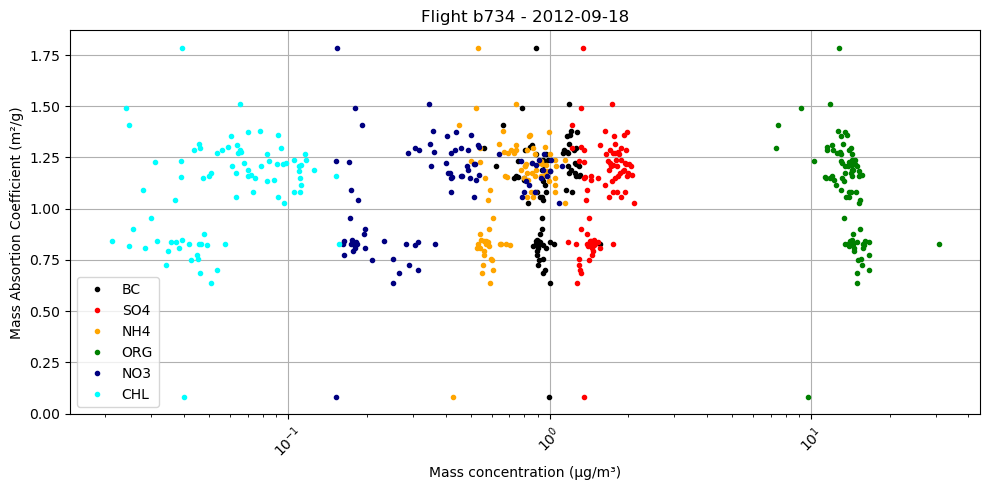

In [60]:
# Create the figure and axis
fig, ax1 = plt.subplots(figsize=(10, 5))

# Define data and corresponding style
species_data = {
    "BC":  (BC_mass_match['BC_mass'].values, "black"),
    "SO4": (SO4_mass_match.values, "red"),
    "NH4": (NH4_mass_match.values, "orange"),
    "ORG": (ORG_mass_match.values, "green"),
    "NO3": (NO3_mass_match.values, "navy"),
    "CHL": (CHL_mass_match.values, "cyan"),
}

# Plot all species in a loop
for label, (xdata, color) in species_data.items():
    ax1.plot(xdata, Mass_absortion_eff.values,
             marker='.', linewidth=0, color=color, label=label)


ax1.set_xscale('log')
# Set labels and formatting
ax1.set_xlabel("Mass concentration (µg/m³)")
ax1.set_ylabel(r'Mass Absortion Coefficient (m²/g)')
ax1.set_title(f"Flight {flight_number} - {flight_date}")
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True)
ax1.legend(loc="best")

plt.tight_layout()
plt.show()

Intercept: 1.1421860448737715
Coefficients:
  BC: 0.2571
  SO4: 0.0013
  NH4: 0.5537
  ORG: -0.0563
  NO3: -0.2827
  CHL: 2.8600

R²: 0.403
RMSE: 0.192


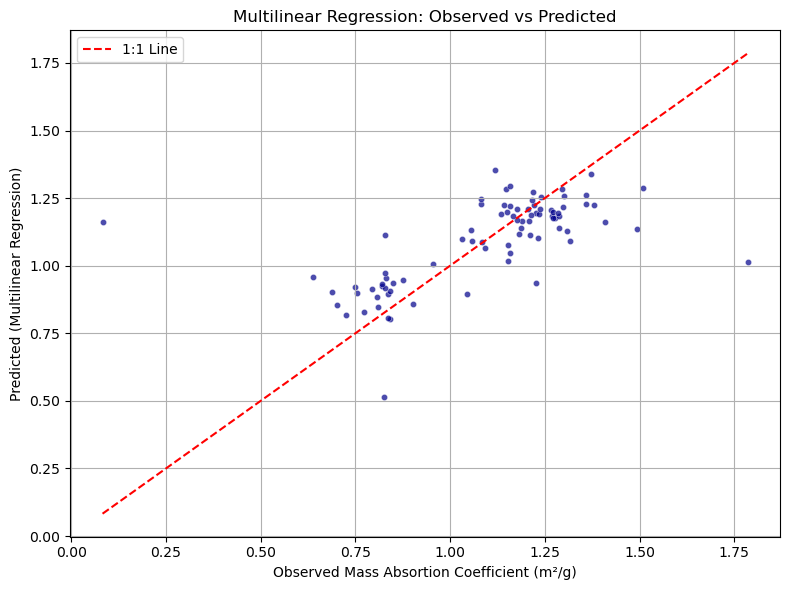

In [61]:
# 1. Prepare input data
X = pd.DataFrame({
    'BC': BC_mass_match['BC_mass'].values,
    'SO4': SO4_mass_match.values,
    'NH4': NH4_mass_match.values,
    'ORG': ORG_mass_match.values,
    'NO3': NO3_mass_match.values,
    'CHL': CHL_mass_match.values
})
y = Mass_absortion_eff.values

# Optional: remove rows with NaNs
valid = X.notnull().all(axis=1) & ~np.isnan(y)
X = X[valid]
y = y[valid]

# 2. Fit linear regression model
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

coeffs = pd.Series(model.coef_, index=X.columns)
intercept = model.intercept_

# 3. Print regression coefficients
print("Intercept:", intercept)
print("Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature}: {coef:.4f}")

# 4. Evaluate model
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
print(f"\nR²: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")

# 5. Plot actual vs predicted
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y, y=y_pred, s=20, color='darkblue', alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='1:1 Line')
plt.xlabel("Observed Mass Absortion Coefficient (m²/g)")
plt.ylabel("Predicted (Multilinear Regression)")
plt.title("Multilinear Regression: Observed vs Predicted")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("MLR_ObservedvsPredicted_absortion.png")
plt.show()



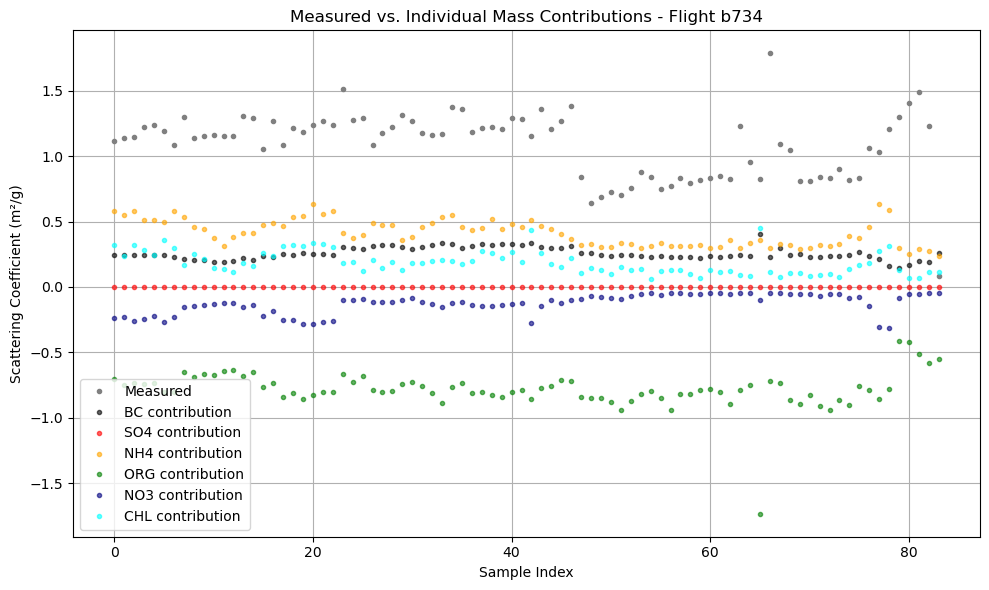

In [62]:
# 6. Plot individual contributions
colors = {
    'BC': 'black',
    'SO4': 'red',
    'NH4': 'orange',
    'ORG': 'green',
    'NO3': 'navy',
    'CHL': 'cyan'
}

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(y, '.', label='Measured', color='gray')

for name in X.columns:
    contribution = X[name] * model.coef_[X.columns.get_loc(name)]
    ax.plot(contribution, '.', label=f"{name} contribution", color=colors[name], alpha=0.6)

ax.set_xlabel("Sample Index")
ax.set_ylabel("Scattering Coefficient (m²/g)")
ax.set_title(f"Measured vs. Individual Mass Contributions - Flight {flight_number}")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


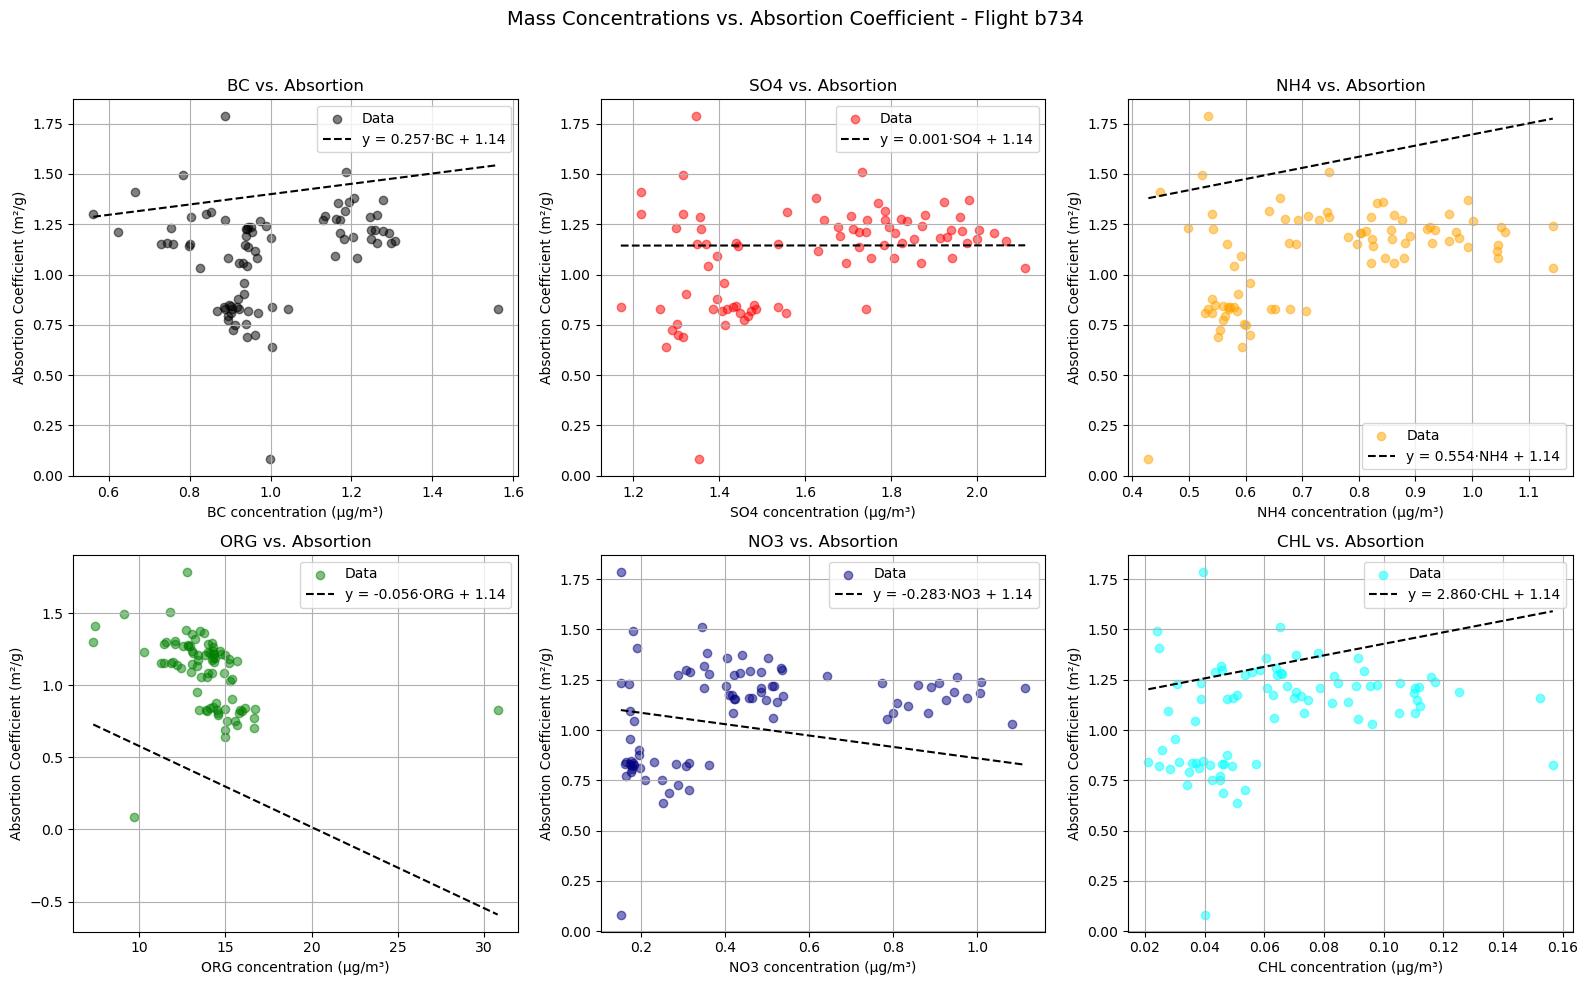

In [63]:
# 4. Scatter plots + linear lines for each variable
colors = {
    'BC': 'black',
    'SO4': 'red',
    'NH4': 'orange',
    'ORG': 'green',
    'NO3': 'navy',
    'CHL': 'cyan'
}

fig, axs = plt.subplots(2, 3, figsize=(16, 10))
axs = axs.flatten()

for i, name in enumerate(X.columns):
    ax = axs[i]
    xi = X[name]
    ci = coeffs[name]

    # Calculate predicted contribution (ci * xi + intercept is not valid here directly)
    # But we just show the line from multilinear coefficient: y = ci * xi + const
    x_range = np.linspace(xi.min(), xi.max(), 100)
    y_line = ci * x_range + intercept  # Intercept here is the total intercept

    ax.scatter(xi, y, alpha=0.5, color=colors[name], label='Data')
    ax.plot(x_range, y_line, color='k', linestyle='--',
            label=f'y = {ci:.3f}·{name} + {intercept:.2f}')

    ax.set_xlabel(f'{name} concentration (µg/m³)')
    ax.set_ylabel('Absortion Coefficient (m²/g)')
    ax.set_title(f'{name} vs. Absortion')
    ax.grid(True)
    ax.legend()

plt.suptitle(f'Mass Concentrations vs. Absortion Coefficient - Flight {flight_number}', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [64]:
# List to store results
results_abs = []

# Iterate over all matching flights
for sp2_file, ams_file, nc_file, neph_file in zip(filtered_sp2, filtered_ams, filtered_nc, filtered_neph):
    
    ds_sp2,ds_ams,ds_neph = dataset_sp2_ams_neph(sp2_file,ams_file,neph_file)
    ds_psap = xr.open_dataset(nc_file)
    
    #Calculate absortion efficiency 
    ds_psap_matched,tm_psap_match,tm_psap_match_unc,test,data_masses=Nc_file_treatment(ds_sp2,ds_ams,ds_psap)
    
    #Calculate Scattering efficiency 
    ds_neph_matched_un,tm_neph_match,tm_neph_match_unc=calculate_scatering_eff_v2(ds_sp2,ds_ams,ds_neph)
    
    #Extract concentration data
    #area_time,data_mass_concentration = Area_plot(ds_sp2,ds_ams,ds_psap)
    
    #Filter absortion data
    #valid_neph_mask = ~np.isnan(ds_neph_matched["TSC_BLUU"])
    #filtered_ds_neph = ds_neph_matched.where(valid_PSAP_mask, drop=TRUE)
    
    
    #Filter absortion data
    #valid_PSAP_mask = ds_psap_matched["PSAP_LIN_FLAG"] == 0
    #filtered_ds_psap = ds_psap_matched.where(valid_PSAP_mask, drop=False)
    #filtered_ds_psap_aux = ds_psap_matched.where(valid_PSAP_mask, drop=False)
    # Ensure both arrays are 1D and aligned
    #psap_values = filtered_ds_psap["PSAP_LIN"]
    #tm_values_psap_match = tm_psap_match.values
    
    #Filter CO and Hight data
    ds_psap_matched_time = test["data_point"].values  # Reference timestamps
    ds_neph_matched_time = ds_neph_matched_un["time"].values
    common_times = np.intersect1d(ds_psap_matched_time, ds_neph_matched_time)
    
    #ds_psap_matched = test.sel(data_point=common_times)
    ds_neph_matched = ds_neph_matched_un.sel(time=common_times)
    tm_neph_match = tm_neph_match.sel(time=common_times)
    BC_mass_match = data_masses[0].sel(time=common_times)
    SO4_mass_match = data_masses[1].sel(time=common_times)
    NH4_mass_match = data_masses[2].sel(time=common_times)
    ORG_mass_match = data_masses[3].sel(time=common_times)
    NO3_mass_match = data_masses[4].sel(time=common_times)
    CHL_mass_match = data_masses[5].sel(time=common_times)
    #mask = ds_psap_matched_un["PSAP_LIN"].notnull()
    #ds_neph_matched = ds_neph_matched_un.where(mask, drop=True)
    
    # Ensure both arrays are 1D and aligned
    #neph_values = ds_neph_matched["TSC_BLUU"].values.squeeze()
    #datetimes = ds_neph_matched["Times"]#.values.squeeze()
    #tm_values_neph_match = tm_neph_match.squeeze()
    
    # Perform element-wise division, ignoring NaNs
    result_abs = np.divide(ds_psap_matched['PSAP_LIN'].values.squeeze(), tm_psap_match*1e-6)
    
    # Drop NaN values from the result if needed
    Mass_absortion_eff = result_abs.where(~np.isnan(result_abs), drop=True)
    
    
    # Compute the mean, handling cases where the list might be empty
    mean_mass_absorption_eff_g = np.nanmean(Mass_absortion_eff) 
    std_mass_absorption_eff_g = np.nanstd(Mass_absortion_eff) 
    mean_std_abs = std_mass_absorption_eff_g/np.sqrt(len(Mass_absortion_eff))
    
    # Extract the flight number (b###) from the file path
    match = re.search(r'b\d{3}', nc_file)  # Looks for 'b' followed by 3 digits
    flight_number = match.group(0) if match else "Unknown"

    # Store results in a list
    results_abs.append({
        'BC': BC_mass_match['BC_mass'].values,
        'SO4': SO4_mass_match.values,
        'NH4': NH4_mass_match.values,
        'ORG': ORG_mass_match.values,
        'NO3': NO3_mass_match.values,
        'CHL': CHL_mass_match.values,
        'Mass Absortion eff': Mass_absortion_eff.values,
        "flight": flight_number
    })


/tmp/ipykernel_737/2261326877.py:62: RuntimeWarning: Mean of empty slice
  mean_mass_absorption_eff_g = np.nanmean(Mass_absortion_eff)
/srv/conda/envs/notebook/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_737/2261326877.py:62: RuntimeWarning: Mean of empty slice
  mean_mass_absorption_eff_g = np.nanmean(Mass_absortion_eff)
/srv/conda/envs/notebook/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [65]:
# Create an empty list to store the summary
regression_results = []

# Loop through each flight dict
for entry in results_abs:
    flight = entry['flight']
    
    # Build X and y from the dictionary
    try:
        X = pd.DataFrame({key: entry[key] for key in ['BC', 'SO4', 'NH4', 'ORG', 'NO3', 'CHL']})
        y = pd.Series(entry['Mass Absortion eff'])
    
        # Remove NaNs (optional safety check)
        valid = X.notnull().all(axis=1) & ~np.isnan(y)
        X = X[valid]
        y = y[valid]
    
        # Add constant (intercept) term
        X_const = sm.add_constant(X)
    
        # Fit model
        model = sm.OLS(y, X_const).fit()
    
        # Add results to the list (one row per parameter)
        for param, coef, std, pval in zip(model.params.index, model.params.values, model.bse.values, model.pvalues.values):
            regression_results.append({
                'Flight': flight,
                'N': len(y),
                'Parameter': param,
                'Coefficient': coef,
                'Std Err': std,
                'p-value': pval,
                'R-squared': model.rsquared if param == 'const' else np.nan,
                'Adj R-squared': model.rsquared_adj if param == 'const' else np.nan,
                'F-statistic': model.fvalue if param == 'const' else np.nan,
                'F p-value': model.f_pvalue if param == 'const' else np.nan
            })


    except Exception as e:
        print(f"Error in flight {flight}: {e}")

# Convert to DataFrame for display
results_df = pd.DataFrame(regression_results)

# Fill R-squared only in one row per flight
results_df['R-squared'] = results_df.groupby('Flight')['R-squared'].transform(lambda x: x.ffill().bfill())

# Display nicely
print(results_df.to_string(index=False))

Error in flight b741: zero-size array to reduction operation maximum which has no identity
Error in flight b747: zero-size array to reduction operation maximum which has no identity
Flight  N Parameter  Coefficient   Std Err      p-value  R-squared  Adj R-squared  F-statistic    F p-value
  b734 84     const     1.142186  0.206059 4.004655e-07   0.403266       0.356767     8.672621 3.267735e-07
  b734 84        BC     0.257095  0.253371 3.134278e-01   0.403266            NaN          NaN          NaN
  b734 84       SO4     0.001342  0.190871 9.944068e-01   0.403266            NaN          NaN          NaN
  b734 84       NH4     0.553674  0.352017 1.198507e-01   0.403266            NaN          NaN          NaN
  b734 84       ORG    -0.056307  0.011107 2.672960e-06   0.403266            NaN          NaN          NaN
  b734 84       NO3    -0.282660  0.312108 3.679465e-01   0.403266            NaN          NaN          NaN
  b734 84       CHL     2.860032  2.006504 1.580885e-01   0.40

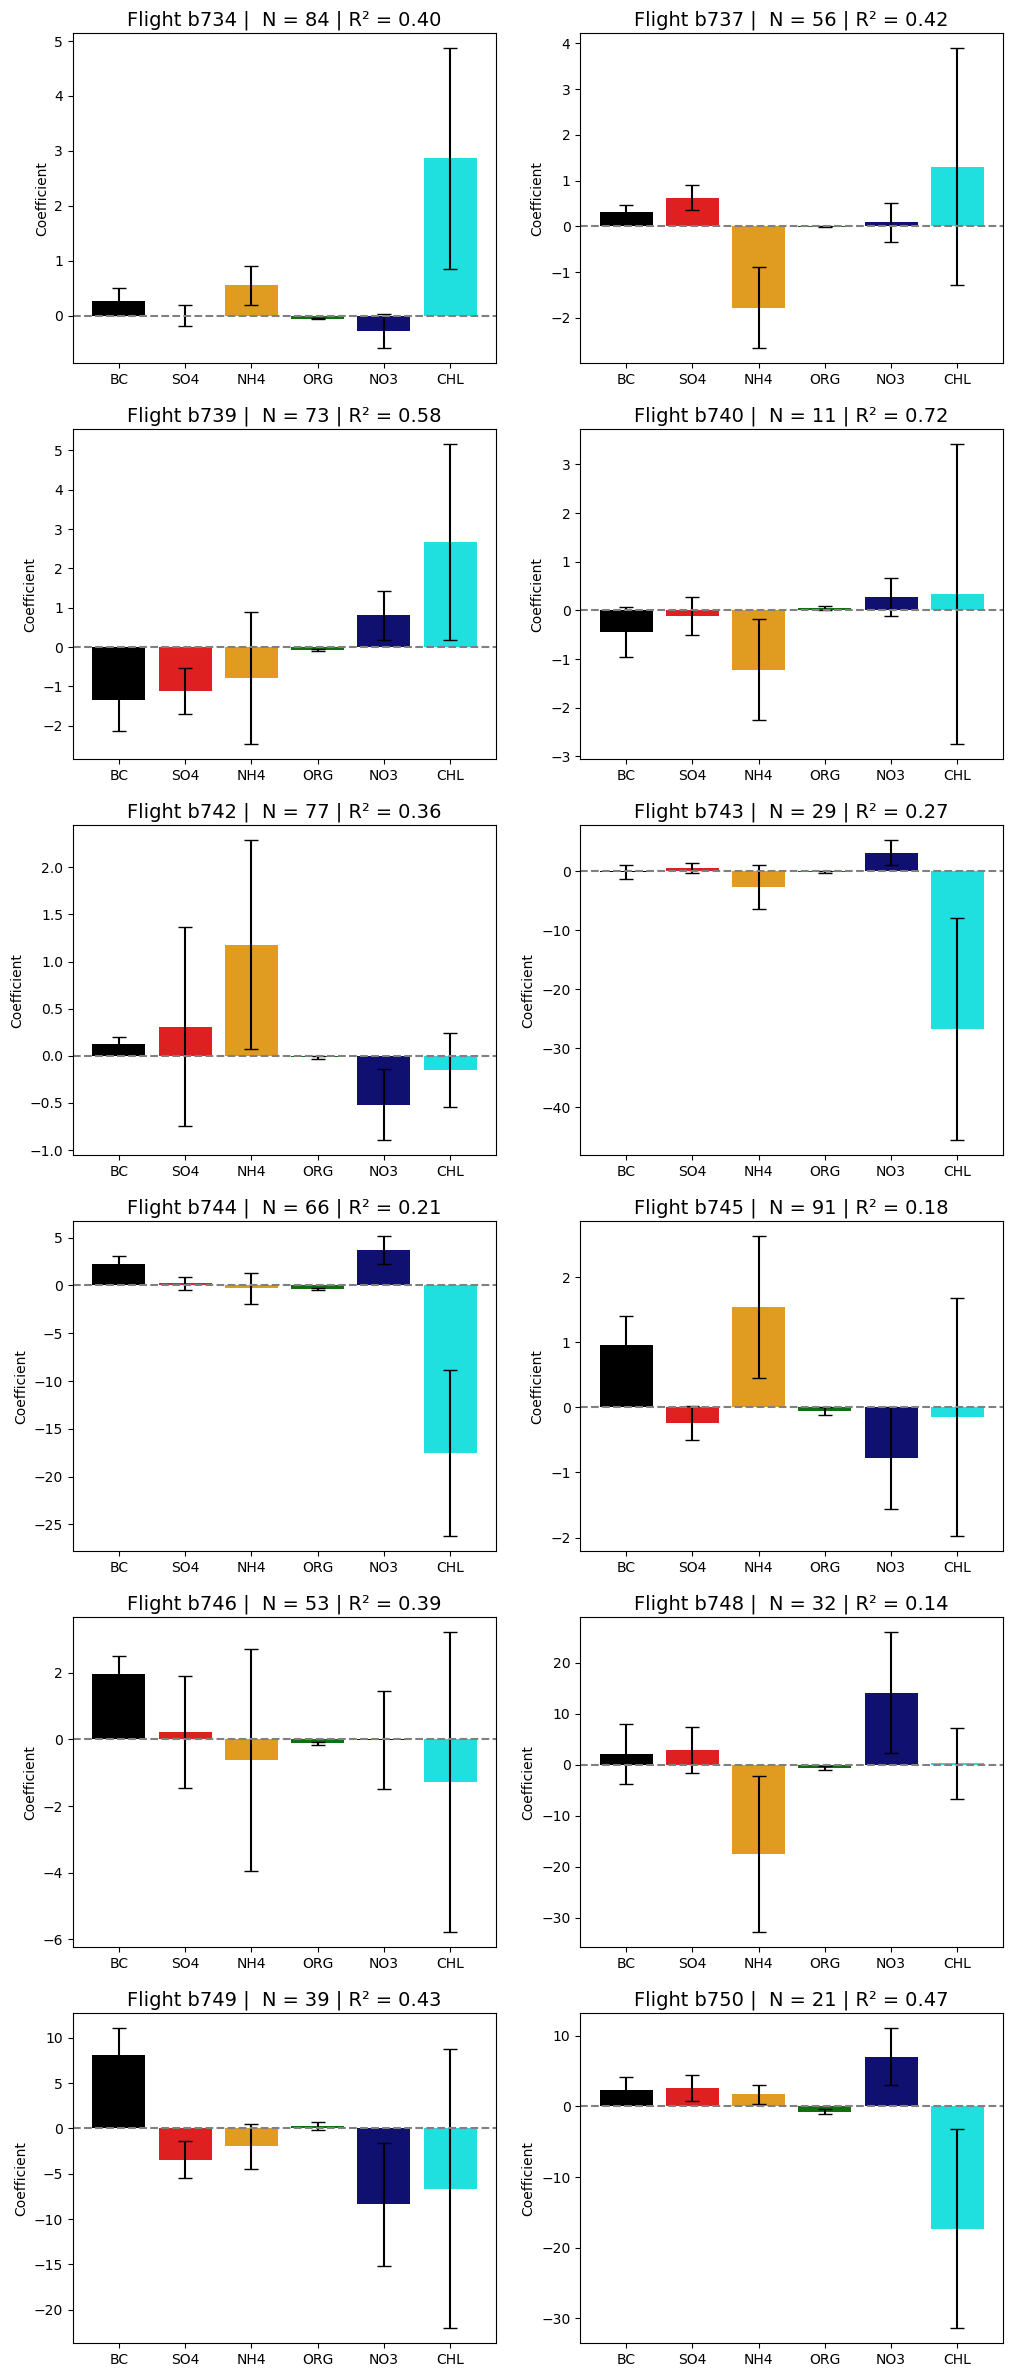

In [66]:
# Filter out constant term
df_coef = results_df[results_df['Parameter'] != 'const'].copy()
flights = df_coef['Flight'].unique()


# Subplot configuration
ncols = 2
nrows = (len(flights) + 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 5 * nrows), squeeze=False)
# Define custom colors for parameters
colors = {
    'BC': 'black',
    'SO4': 'red',
    'NH4': 'orange',
    'ORG': 'green',
    'NO3': 'navy',
    'CHL': 'cyan'
}

for idx, flight in enumerate(flights):
    ax = axes[idx // ncols, idx % ncols]

    # Subset for current flight
    flight_df = df_coef[df_coef['Flight'] == flight]
    N = flight_df['N'].unique()[0]
    model_info_query = results_df[(results_df['Flight'] == flight) & (results_df['Parameter'] == 'const')]

    if model_info_query.empty:
        print(f"⚠️  Warning: 'const' parameter missing for Flight {flight}. Skipping plot.")
        ax.set_visible(False)
        continue

    model_info = model_info_query.iloc[0]

    # Barplot with custom colors
    sns.barplot(
        data=flight_df,
        x='Parameter', y='Coefficient',
        hue='Parameter', palette=colors,
        errorbar=None, ax=ax, legend=False
    )

    # Error bars
    ax.errorbar(
        x=range(len(flight_df)),
        y=flight_df['Coefficient'],
        yerr=flight_df['Std Err'],
        fmt='none', c='black', capsize=5
    )

    ax.axhline(0, color='gray', linestyle='--')
    ax.set_title(f"Flight {flight} |  N = {N} | R² = {model_info['R-squared']:.2f}", fontsize=14)
    ax.set_ylabel("Coefficient")
    ax.set_xlabel("")
plt.savefig("MLR_coefficients_absortion.png")